https://www.nb-data.com/p/rag-reranking-to-elevate-retrieval?utm_source=chatgpt.com

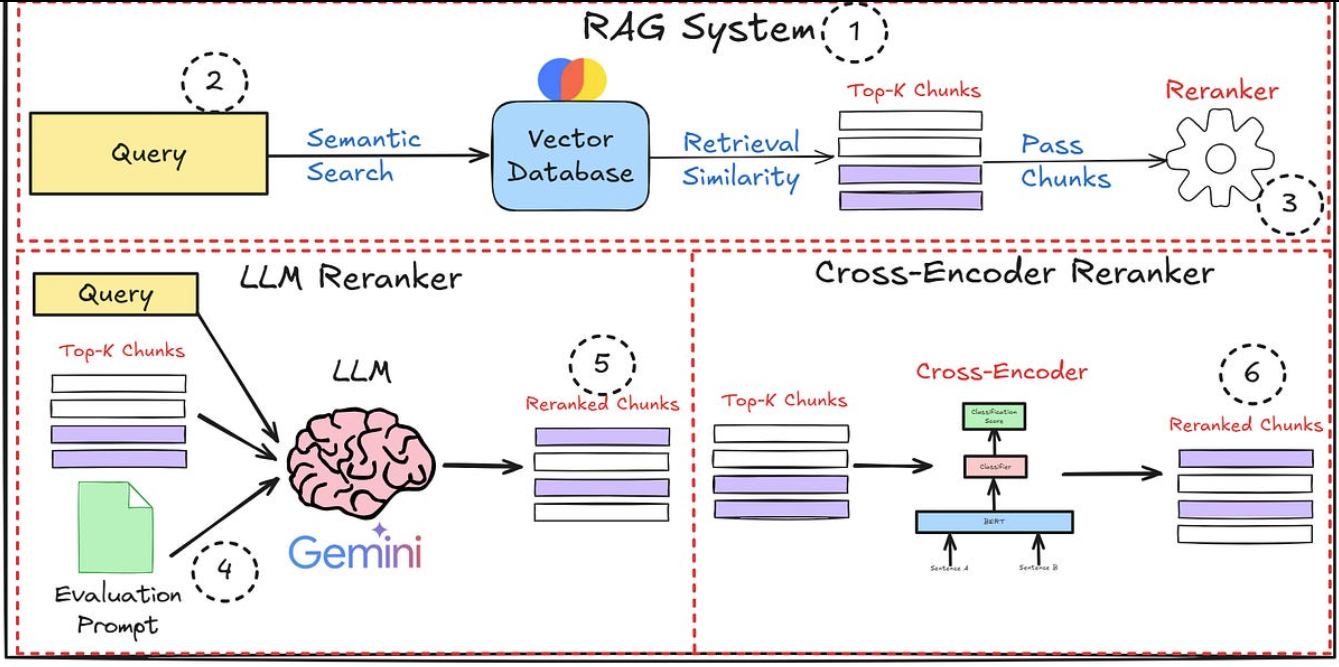

In [1]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser 

In [13]:
## load text file
loader=TextLoader("langchain_sample_doc.txt")
raw_docs=loader.load()

# Split text into document chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs = splitter.split_documents(raw_docs)
docs


[Document(metadata={'source': 'langchain_sample_doc.txt'}, page_content='LangChain is a flexible framework designed for developing applications powered by large language models (LLMs). It provides tools and abstractions to work with LLMs more effectively and includes components for prompt management, chains, memory, and agents.'),
 Document(metadata={'source': 'langchain_sample_doc.txt'}, page_content='LangChain integrates with many third-party services such as OpenAI, Hugging Face, and Cohere. This enables developers to experiment with different models and optimize performance for specific use cases like summarization, question answering, or translation.'),
 Document(metadata={'source': 'langchain_sample_doc.txt'}, page_content='Retrieval-Augmented Generation (RAG) is a powerful technique where external knowledge is retrieved and passed into the prompt to ground LLM responses. LangChain makes it easy to implement RAG using vector databases like FAISS, Chroma, and Pinecone.\nBM25 is a 

In [14]:
## user query
query="How can i use langchain to build an application with memory and tools?"

In [15]:
### FAISS and Huggingface model Embeddings

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore=FAISS.from_documents(docs,embedding_model)
retriever=vectorstore.as_retriever(search_kwargs={"k":8})

In [29]:
## OpenAI Embedding
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
from langchain_openai import OpenAIEmbeddings

embeddings=OpenAIEmbeddings()
vectorstore_openai=FAISS.from_documents(docs,embeddings)
retriever_openai=vectorstore_openai.as_retriever(search_kwargs={"k":8})


In [30]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000028F392F48C0>, search_kwargs={'k': 8})

In [31]:
import os
from dotenv import load_dotenv
load_dotenv()
## prompt and use the llm
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=init_chat_model("groq:gemma2-9b-it")
llm

ChatGroq(profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028F7C6AC620>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028F7D3A28A0>, model_name='gemma2-9b-it', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [32]:
# Prompt Template
prompt = PromptTemplate.from_template("""
You are a helpful assistant. Your task is to rank the following documents from most to least relevant to the user's question.

User Question: "{question}"

Documents:
{documents}

Instructions:
- Think about the relevance of each document to the user's question.
- Return a list of document indices in ranked order, starting from the most relevant.

Output format: comma-separated document indices (e.g., 2,1,3,0,...)
""")

In [33]:
retrieved_docs = retriever.invoke(query)
retrieved_docs

[Document(id='cc6329de-1649-434a-b3a6-e1daa5a2b942', metadata={'source': 'langchain_sample_doc.txt'}, page_content='LangChain supports tool integration including web search, calculators, and APIs, allowing LLMs to interact with external systems and respond more accurately to dynamic queries.\nMemory in LangChain enables context retention across multiple steps in a conversation or task, making the application more coherent and stateful.'),
 Document(id='5e577a4a-eddf-4034-b579-eeb8148ae6b5', metadata={'source': 'langchain_sample_doc.txt'}, page_content='LangChain is a flexible framework designed for developing applications powered by large language models (LLMs). It provides tools and abstractions to work with LLMs more effectively and includes components for prompt management, chains, memory, and agents.'),
 Document(id='e86ab1c7-643c-4b3b-b4dc-c7a273ad5f3c', metadata={'source': 'langchain_sample_doc.txt'}, page_content='LangChain integrates with many third-party services such as OpenA

In [26]:
doc_lines = [f"{i+1}. {doc.page_content}" for i, doc in enumerate(retrieved_docs)]
formatted_docs = "\n".join(doc_lines)


In [27]:
formatted_docs

'1. LangChain supports tool integration including web search, calculators, and APIs, allowing LLMs to interact with external systems and respond more accurately to dynamic queries.\nMemory in LangChain enables context retention across multiple steps in a conversation or task, making the application more coherent and stateful.\n2. LangChain is a flexible framework designed for developing applications powered by large language models (LLMs). It provides tools and abstractions to work with LLMs more effectively and includes components for prompt management, chains, memory, and agents.\n3. LangChain integrates with many third-party services such as OpenAI, Hugging Face, and Cohere. This enables developers to experiment with different models and optimize performance for specific use cases like summarization, question answering, or translation.\n4. FAISS is a popular library used for fast approximate nearest neighbor search in high-dimensional spaces. It supports both flat and compressed ind

In [ ]:

chain = prompt |llm|StrOutputParser()
chain

PromptTemplate(input_variables=['documents', 'question'], input_types={}, partial_variables={}, template='\nYou are a helpful assistant. Your task is to rank the following documents from most to least relevant to the user\'s question.\n\nUser Question: "{question}"\n\nDocuments:\n{documents}\n\nInstructions:\n- Think about the relevance of each document to the user\'s question.\n- Return a list of document indices in ranked order, starting from the most relevant.\n\nOutput format: comma-separated document indices (e.g., 2,1,3,0,...)\n')
| ChatGroq(profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028F3BFA91C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028F380AEDE0>, model_name='gemm

In [34]:
response = chain.invoke({"question" : query, "documents" : formatted_docs})

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}